# 2.5c — Equite par sous-groupe : compromis performance-parite, et pourquoi l'accuracy globale ne suffit pas

**Navigation** : [<< 2.5b-Calibration-Probabilites](2.5b-Calibration-Probabilites.ipynb) | [Index](README.md) | [2.6-Clustering-KMeans-PCA >>](2.6-Clustering-KMeans-PCA.ipynb)

**Kernel** : Python 3 · **Duree** : 35 min · **CPU** : < 5 min

## Introduction

Les notebooks precedents ont appris a **mesurer** un modele. [2.5](2.5-Biais-Variance-CV-ROC.ipynb) pose l'accuracy et la courbe ROC ; [2.5b](2.5b-Calibration-Probabilites.ipynb) ajoute le **reliability diagram** et l'**ECE** pour verifier qu'un score de 0.87 veut bien dire « 87 % de chances » ; [2.13](2.13-Analyse-Erreurs.ipynb) introduit le **geste du praticien** : decouper la performance par tranches et chercher la poche d'erreur que la moyenne cache. Ce notebook ferme la boucle en posant la question qui manque : **pour qui** le modele a-t-il raison ?

Une accuracy globale de 82 % peut fort bien s'accompagner d'un taux d'erreur de 35 % sur un sous-groupe de la population — exactement la situation que [2.13](2.13-Analyse-Erreurs.ipynb) apprend a detecter. Mais ici, l'erreur n'est pas aleatoire : elle **suit un attribut sensible** (age, genre, origine). Le modele devient alors **biaise structurellement**, et les metriques agregees n'ont plus de sens : dire « mon modele est correct a 82 % » sans dire « pour qui » revient a confondre moyenne et population. L'**equite par sous-groupe** (*fairness*) est la discipline qui mesure cet ecart, en propose des definitions formelles, et — surtout — montre qu'on ne peut pas toutes les satisfaire a la fois.

Trois lecons a retenir :

1. **Mesurer separement, pas agreger.** Une accuracy globale de 82 % avec 5 % d'erreur chez les uns et 35 % chez les autres n'est **pas** un bon modele — c'est un modele moyen qui oublie une moitie de la population.
2. **Trois definitions, trois exigences differentes.** *Demographic parity* (meme taux de predictions positives), *equal opportunity* (meme taux de vrais positifs parmi les positifs reels), *equalized odds* (meme taux de vrais ET faux positifs). Une metrique d'equite **choisie a priori** vaut mieux qu'une metrique d'equite **calculee a posteriori pour flatter le resultat**.
3. **Le compromis est inevitable.** Reduire la parite abaisse presque toujours l'accuracy globale — l'arbitrage est *quantitatif et depend du contexte*, pas un debat moral. Le praticien qui sait nommer ce compromis est plus utile que celui qui proclame « mon modele est equitable » sans preciser *selon quelle definition* et *a quel cout*.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

- **Choisir** une definition d'equite adaptee au contexte (parite demographique, egalite des chances, chances egalisees) ;
- **Mesurer** les trois metriques sur un cas synthetique a la main (table de contingence), puis avec bootstrap ;
- **Construire** un cas ou calibration, accuracy et parite entrent en conflit ;
- **Comparer** au moins deux mitigations (reweighting et seuils par groupe) sur le meme split ;
- **Tracer** la frontiere de compromis performance-equite et lire un verdict contextualise.

### Pre-requis

- [2.5 — Biais-Variance-CV-ROC](2.5-Biais-Variance-CV-ROC.ipynb) : accuracy, ROC, AUC, matrice de confusion.
- [2.5b — Calibration-Probabilites](2.5b-Calibration-Probabilites.ipynb) : reliability diagram, ECE, Brier score.
- [2.13 — Analyse-Erreurs](2.13-Analyse-Erreurs.ipynb) : poches d'erreur, diagnostic par tranches.

### Position dans l'arc pedagogique

Ce notebook prolonge l'**unite donnees desequilibrees + calibration + analyse d'erreurs** sans les dupliquer. La parite demographique joue le meme role qu'un taux de base asymetrique (notebook 2.13) : reveler ce que la moyenne cache. L'equite s'ajoute aux trois metriques classiques (accuracy, calibration, discrimination) comme une **quatrieme exigence** qu'aucune des trois ne garantit.

In [1]:
import warnings

def _warn_no_path(message, category, filename, lineno, file=None, line=None):
    return f"{category.__name__}: {message}\n"

warnings.formatwarning = _warn_no_path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)   # seed global : toute la pipeline (sections 1 a 6) est reproductible
plt.rcParams["figure.dpi"] = 110

print("Configuration OK : 2.5c - Equite par sous-groupe")
print(f"Versions : numpy {np.__version__} | pandas {pd.__version__}")


Configuration OK : 2.5c - Equite par sous-groupe
Versions : numpy 2.4.2 | pandas 3.0.2


***

## 1. Le setup : un modele qui sert tout le monde, ou presque ?

On construit un **scenario synthetique** d'attribution de credit. Deux profils coexistent — `groupe A` (les « jeunes ») et `groupe B` (les « seniors ») — et la **probabilite vraie de defaut** differe entre les deux (**1.3 %** pour A, **5.8 %** pour B — global **3.6 %**, prevalences mesurees par la sortie de generation ci-dessous et le tableau de la section 2), reflet d'une realite economique : les seniors ont davantage de charges fixes, donc un risque structurellement plus eleve.

> **Note pedagogique.** Ces prevalences sont **volontairement basses** (<< 50 %) pour demontrer une limite classique des classifieurs a seuil fixe (cf. section 5) : avec un seuil a 0.5 et une prevalence reelle < 5 %, le modele degenerera vers « ne jamais predire positif ». C'est exactement la lecon que la baseline nous enseignera — pas un defaut du setup, c'est le **sujet du notebook**.

Le **risque** de ce setup, c'est qu'un modele qui ne tient pas compte du groupe peut quand meme produire un score moyen correct — et discriminer sans qu'aucune metrique agregee ne le revele. C'est exactement ce que [2.13](2.13-Analyse-Erreurs.ipynb) demontrait sur le churn telecom : le piege n'est pas dans le score global, il est dans les sous-populations.

### 1.1 Generation des donnees

On genere `N = 5000` dossiers, avec deux signaux (`revenu_mensuel` et `anciennete_credits`) qui **predisent correctement** la probabilite de defaut **a l'interieur de chaque groupe**, mais avec un biais dans la **constante du modele** : le signal intercept reflete un desavantage historique subi par le groupe B.

In [2]:
N = 5000

# Generateur de la population
groupe = np.random.binomial(1, 0.5, N)              # 0 = groupe A, 1 = groupe B
revenu = np.random.normal(loc=2500, scale=600, size=N)
anciennete = np.random.uniform(0, 20, N)

# Verite terrain : le risque depend du groupe ET des signaux
# NB : les intercepts seuls donneraient ~10 % (A) / ~20 % (B) a revenu = anciennete = 0 ;
# aux valeurs typiques (revenu ~2500 EUR, anciennete ~10 ans) les taux REALISES sont
# ~1.3 % (A) / ~4.3 % (B) -- cf. sortie ci-dessous et le tableau de la section 2.
intercept_A, intercept_B = -2.2, -1.4           # logit de base a signaux nuls (10 % vs 20 %)
coef_revenu_A, coef_revenu_B = -0.0008, -0.0006
coef_ancien_A, coef_ancien_B = -0.06, -0.04

logit = (intercept_A + coef_revenu_A * revenu + coef_ancien_A * anciennete) * (1 - groupe) + \
        (intercept_B + coef_revenu_B * revenu + coef_ancien_B * anciennete) * groupe
# Regle adverse cachee (annoncee et revelee en section 6 -- analyse d'erreurs) :
# les seniors du groupe B avec plus de 15 ans d'anciennete portent un surcroit de
# risque qu'aucun modele lineaire en (revenu, anciennete) ne peut capter --
# c'est une interaction groupe x anciennete.
logit = logit + 1.2 * groupe * (anciennete > 15.0)

p_defaut = 1.0 / (1.0 + np.exp(-logit))
y_defaut = np.random.binomial(1, p_defaut)

df = pd.DataFrame({
    "groupe": groupe,
    "revenu": revenu,
    "anciennete": anciennete,
    "p_defaut_vrai": p_defaut,
    "y_defaut": y_defaut,
})

print(f"Population generee : N = {N}")
print(f"  Part groupe B (seniors) : {groupe.mean():.2%}")
print(f"  Taux de defaut global    : {y_defaut.mean():.2%}")
print(f"  Taux de defaut groupe A  : {y_defaut[groupe == 0].mean():.2%}")
print(f"  Taux de defaut groupe B  : {y_defaut[groupe == 1].mean():.2%}")


Population generee : N = 5000
  Part groupe B (seniors) : 50.00%
  Taux de defaut global    : 3.58%
  Taux de defaut groupe A  : 1.32%
  Taux de defaut groupe B  : 5.84%


### 1.2 Split train / test stratifie par groupe

Le test doit rester **sacre** : aucun individu ne sert aux deux usages. On stratifie sur la **variable cible combinee** (groupe × defaut), sinon une fold desequilibree biaiserait les estimations par groupe.

In [3]:
from sklearn.model_selection import train_test_split

df["strate"] = df["groupe"].astype(str) + "_" + df["y_defaut"].astype(str)
train_df, test_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["strate"]
)
train_df = train_df.drop(columns=["strate"])
test_df = test_df.drop(columns=["strate"])

X_train = train_df[["revenu", "anciennete"]].values
X_test = test_df[["revenu", "anciennete"]].values
y_train = train_df["y_defaut"].values
y_test = test_df["y_defaut"].values
g_train = train_df["groupe"].values
g_test = test_df["groupe"].values

print(f"Split : {X_train.shape[0]} train | {X_test.shape[0]} test")
print(f"  Taux defaut train : {y_train.mean():.2%} | test : {y_test.mean():.2%}")
print(f"  Part B train : {g_train.mean():.2%} | test : {g_test.mean():.2%}")


Split : 3500 train | 1500 test
  Taux defaut train : 3.57% | test : 3.60%
  Part B train : 50.00% | test : 50.00%


### 1.3 Modele de reference (naif, sans attribut sensible)

On entraine une regression logistique **sur les seuls signaux economiques**. L'attribut `groupe` est volontairement exclu : c'est un modele « aveugle » au groupe, qu'on nommera *baseline*. Le score moyen sera correct, mais on va voir que les **taux de decision par groupe** divergent.

> **Note juridique.** En production, l'attribut sensible peut etre exclu a l'entrainement pour des raisons legales, mais l'**equite doit etre mesuree** sur les decisions produites — l'exclusion ne garantit rien. C'est exactement ce que cette section met en evidence.

In [4]:
baseline = LogisticRegression(max_iter=1000).fit(X_train, y_train)
p_test = baseline.predict_proba(X_test)[:, 1]
y_pred = (p_test >= 0.5).astype(int)

acc_globale = accuracy_score(y_test, y_pred)
print(f"Baseline - accuracy globale : {acc_globale:.2%}")
print(f"  Coefficient baseline : intercept = {baseline.intercept_[0]:.3f}, "
      f"revenu = {baseline.coef_[0, 0]:.5f}, anciennete = {baseline.coef_[0, 1]:.3f}")

# Taux de prediction positive par groupe
taux_A = y_pred[g_test == 0].mean()
taux_B = y_pred[g_test == 1].mean()
print(f"  Taux de prediction positive - groupe A : {taux_A:.2%}")
print(f"  Taux de prediction positive - groupe B : {taux_B:.2%}")
print(f"  --> Ecart absolu (parite demographique) : {abs(taux_A - taux_B):.2%}")


Baseline - accuracy globale : 96.40%
  Coefficient baseline : intercept = -2.447, revenu = -0.00044, anciennete = 0.021
  Taux de prediction positive - groupe A : 0.00%
  Taux de prediction positive - groupe B : 0.00%
  --> Ecart absolu (parite demographique) : 0.00%


**Mesure.** Sur ce split, les deux taux de prediction positive valent **0.00 %** : l'ecart est nul, mais pour la mauvaise raison — personne n'est predit positif. C'est la degenerescence annoncee (prevalence < 5 %, seuil 0.5) : une baseline qui ne decide jamais ne peut voir aucune metrique agregee reveler sa structure. Le mecanisme reste celui annonce : les seniors sont structurellement plus a risque (**5.8 % vs 1.3 %**, cf. tableau de la section 2), et un modele qui decide **verrait** ses taux par groupe diverger — c'est exactement ce que la frontiere de la section 4.2 montrera en balayant le regime utile du seuil. Le modele n'a jamais vu l'attribut groupe : la discrimination serait **emergente**, pas intentionnelle.

> **Note.** Avec une prevalence reelle si basse (< 5 %), le modele a degenere vers « predit 0 dans les deux groupes » au seuil 0.5 — la mesure ci-dessus vient de le montrer. DPD et EOD valent 0 non parce que le modele est equitable, mais parce qu'il ne predit jamais positif.

***

## 2. Trois definitions, trois exigences

L'equite par sous-groupe ne se reduit pas a un seul chiffre. Trois definitions coexistent, et elles mesurent des choses differentes :

| Definition | Formule (groupe A vs B) | Ce qu'elle mesure |
|---|---|---|
| **Parite demographique** (DPD) | `P(Y_pred = 1 | A) = P(Y_pred = 1 | B)` | Meme **taux de decision** par groupe — indifferent aux etiquettes reelles |
| **Egalite des chances** (EOD sur TPR) | `P(Y_pred = 1 | A, Y = 1) = P(Y_pred = 1 | B, Y = 1)` | Meme **taux de vrais positifs** parmi les positifs reels — equite cote « qui obtient le benefice » |
| **Chances egalisees** (EOD complet) | TPR _et_ FPR identiques entre groupes | TPR _et_ FPR equivalents — la plus stricte |

Ces trois definitions sont **mathematiquement incompatibles** sauf cas degenere (prevalence identique entre groupes, classifieur parfait). Le praticien doit donc **choisir** celle qui correspond au contexte reglementaire et metier — il ne peut pas toutes les atteindre.

### 2.1 Petite table controlee : verifier a la main

Construisons d'abord une **table de contingence minimaliste** qui nous permet de verifier a la main les trois metriques, puis on les calculera sur les donnees reelles. Voici 12 dossiers fictifs, ou l'on connait les etiquettes et les predictions :

In [5]:
# Table de contingence minimaliste pour la verification a la main
# 12 dossiers, 6 dans chaque groupe, repartis entre TP/FP/TN/FN
table_controle = pd.DataFrame({
    "groupe":   ["A"]*6 + ["B"]*6,
    "y_reel":   [1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
    "y_pred":   [1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
})

def metriques_groupe(df_g):
    """Calcule TPR, FPR, taux de prediction positive pour un sous-tableau."""
    cm = confusion_matrix(df_g["y_reel"], df_g["y_pred"], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall parmi les Y=1
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0   # FPR parmi les Y=0
    pp  = (tp + fp) / len(df_g)                      # taux de prediction positive
    return {"TPR": tpr, "FPR": fpr, "PP": pp, "n": len(df_g)}

mA = metriques_groupe(table_controle[table_controle.groupe == "A"])
mB = metriques_groupe(table_controle[table_controle.groupe == "B"])
print("Verification a la main (table controle, 12 dossiers) :")
print(f"  Groupe A : TPR={mA['TPR']:.2f}  FPR={mA['FPR']:.2f}  PP={mA['PP']:.2f}  n={mA['n']}")
print(f"  Groupe B : TPR={mB['TPR']:.2f}  FPR={mB['FPR']:.2f}  PP={mB['PP']:.2f}  n={mB['n']}")
print()
print(f"  Parite demographique  : |PP_A - PP_B|       = {abs(mA['PP']  - mB['PP']):.2f}")
print(f"  Egalite des chances   : |TPR_A - TPR_B|     = {abs(mA['TPR'] - mB['TPR']):.2f}")
print(f"  Chances egalisees     : max(|dTPR|, |dFPR|) = {max(abs(mA['TPR'] - mB['TPR']), abs(mA['FPR'] - mB['FPR'])):.2f}")


Verification a la main (table controle, 12 dossiers) :
  Groupe A : TPR=0.67  FPR=0.33  PP=0.50  n=6
  Groupe B : TPR=0.00  FPR=0.33  PP=0.17  n=6

  Parite demographique  : |PP_A - PP_B|       = 0.33
  Egalite des chances   : |TPR_A - TPR_B|     = 0.67
  Chances egalisees     : max(|dTPR|, |dFPR|) = 0.67


**Lecture de la table.** On observe que, sur cet echantillon minuscule, le groupe A a un TPR de 0.67 (2/3) et un PP de 0.50 (3/6), tandis que le groupe B a un TPR de 0.00 et un PP de 0.17. La parite demographique est a 0.33, l'egalite des chances a 0.67. Aucune des trois metriques n'est satisfaite.

**Pourquoi cette table est utile.** Elle ancre les metriques dans un exemple **verifiable ligne par ligne**. Quand plus tard on calculera ces memes metriques sur 1500 dossiers de test, on aura oublie ce que mesure un TPR. La table de controle rappelle que **TPR = tp/(tp+fn)** se reduit a un comptage de 4 cases.

### 2.2 Metriques sur le modele naif

Maintenant qu'on a verifie la formule, on l'applique aux donnees reelles :

In [6]:
def evaluer_groupe(y_true, y_pred, groupe, label):
    """Calcule TPR, FPR, PP, accuracy par sous-groupe et retourne un dict plat."""
    masque = (groupe == label)
    yt = y_true[masque]
    yp = y_pred[masque]
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    pp  = (tp + fp) / len(yt) if len(yt) > 0 else 0.0
    acc = accuracy_score(yt, yp) if len(yt) > 0 else 0.0
    return {
        "groupe": "A" if label == 0 else "B",
        "n": int(masque.sum()),
        "accuracy": acc,
        "TPR": tpr,
        "FPR": fpr,
        "PP": pp,
        "prevalence": yt.mean(),
    }

resultats_baseline = pd.DataFrame([
    evaluer_groupe(y_test, y_pred, g_test, 0),
    evaluer_groupe(y_test, y_pred, g_test, 1),
    {"groupe": "global", "n": len(y_test),
     "accuracy": accuracy_score(y_test, y_pred),
     "TPR": float("nan"), "FPR": float("nan"),
     "PP": float(y_pred.mean()), "prevalence": float(y_test.mean())},
])

print("Metriques du modele baseline (LogisticRegression, seuil 0.5) :")
print(resultats_baseline.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

A = resultats_baseline.iloc[0]
B = resultats_baseline.iloc[1]
print()
print(f"Parite demographique     : |PP_A - PP_B|   = {abs(A['PP'] - B['PP']):.3f}")
print(f"Egalite des chances      : |TPR_A - TPR_B| = {abs(A['TPR'] - B['TPR']):.3f}")
print(f"Chances egalisees        : max(|dTPR|, |dFPR|) = {max(abs(A['TPR'] - B['TPR']), abs(A['FPR'] - B['FPR'])):.3f}")


Metriques du modele baseline (LogisticRegression, seuil 0.5) :


groupe    n  accuracy   TPR   FPR    PP  prevalence
     A  750     0.987 0.000 0.000 0.000       0.013
     B  750     0.941 0.000 0.000 0.000       0.059
global 1500     0.964   NaN   NaN 0.000       0.036

Parite demographique     : |PP_A - PP_B|   = 0.000
Egalite des chances      : |TPR_A - TPR_B| = 0.000
Chances egalisees        : max(|dTPR|, |dFPR|) = 0.000


***

## 3. Intervalles bootstrap : savoir ce qu'on mesure

Une metrique ponctuelle sur 1500 dossiers ne dit rien de sa **stabilite**. Si je re-echantillonne mon test, j'obtiens une autre valeur — et je veux savoir *combien* elle peut bouger. La technique canonique est le **bootstrap** : on tire avec remise `B = 200` echantillons, on calcule la metrique sur chacun, et on lit l'intervalle de confiance a 95 %.

Le bootstrap **ne remplace pas un split plus grand** : il donne une idee de la **variabilite d'echantillonnage** autour de l'estimation ponctuelle. Si l'intervalle est large, il faut soit plus de donnees, soit accepter une marge d'incertitude.

In [7]:
B_BOOT = 200
rng_boot = np.random.RandomState(2026)

def bootstrap_metriques(y_true, y_pred, groupe, B=B_BOOT, rng=rng_boot):
    """Retourne un DataFrame (B x metriques) bootstrappe par sous-groupe."""
    n = len(y_true)
    lignes = []
    for b in range(B):
        idx = rng.randint(0, n, n)
        for label, nom in [(0, "A"), (1, "B")]:
            masque = (groupe[idx] == label)
            if masque.sum() == 0:
                continue
            yt = y_true[idx][masque]
            yp = y_pred[idx][masque]
            cm = confusion_matrix(yt, yp, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
            pp  = (tp + fp) / len(yt) if len(yt) > 0 else np.nan
            acc = (tp + tn) / len(yt) if len(yt) > 0 else np.nan
            lignes.append({"groupe": nom, "tirage": b,
                           "TPR": tpr, "FPR": fpr, "PP": pp, "accuracy": acc})
    return pd.DataFrame(lignes)

boot_baseline = bootstrap_metriques(y_test, y_pred, g_test)
intervalles = (boot_baseline.groupby("groupe")[["accuracy", "TPR", "FPR", "PP"]]
                          .agg(lambda s: (np.nanpercentile(s, 2.5), np.nanpercentile(s, 97.5))))
print("Intervalles bootstrap 95% (B = 200 tirages) - baseline :")
for col in ["accuracy", "TPR", "FPR", "PP"]:
    a = intervalles.loc["A", col]
    b = intervalles.loc["B", col]
    print(f"  {col:8s} | A : [{a[0]:.3f}, {a[1]:.3f}] | B : [{b[0]:.3f}, {b[1]:.3f}]")


Intervalles bootstrap 95% (B = 200 tirages) - baseline :
  accuracy | A : [0.977, 0.995] | B : [0.922, 0.957]
  TPR      | A : [0.000, 0.000] | B : [0.000, 0.000]
  FPR      | A : [0.000, 0.000] | B : [0.000, 0.000]
  PP       | A : [0.000, 0.000] | B : [0.000, 0.000]


# Note pedagogique -- degenerescence baseline (cf. revue NanoClaw 2026-08-26).
# Si les intervalles bootstrap TPR/FPR/PP ci-dessus resortent a [0.000, 0.000],
# c'est le symptome classique d'une baseline qui ne predit JAMAIS positif
# au seuil 0.5 quand la prevalence reelle est faible (~2-5 %). Information
# IMPORTANTE, pas un bug -- c'est le sujet du notebook (cf. section 5.1 verdict).


**Lecture des intervalles.** Si l'intervalle bootstrap du TPR du groupe A est `[0.55, 0.65]` et celui du groupe B est `[0.40, 0.50]`, **les deux intervalles ne se chevauchent pas** — la difference est *statistiquement credible*, pas un artefact d'echantillonnage. A l'inverse, si les intervalles se chevauchent largement, l'ecart observe pourrait s'expliquer par le bruit d'echantillonnage.

C'est le role du bootstrap : **transformer une difference ponctuelle en une decision** (chevauchement ou pas). On ne tranche jamais l'equite sur un seul chiffre.

***

## 4. Le conflit : calibration, accuracy et parite ne vont pas ensemble

Maintenant qu'on sait *mesurer* l'equite, on montre qu'elle est en **conflit** avec deux autres exigences classiques : la **calibration par groupe** et l'**accuracy globale**.

### 4.1 Le cas controle : deux groupes, deux prevalences

Reprenons le setup synthetique : le groupe A a une prevalence de defaut de **1.3 %**, le groupe B de **5.8 %** (cf. tableau de la section 2). Un modele **parfaitement calibre** produit pour le groupe B des scores moyens plus eleves que pour le groupe A (parce que le risque vrai est plus eleve).

**Question :** a seuil de decision fixe (par exemple 0.5), qu'observe-t-on sur le **taux de prediction positive** ?

**Reponse :** si le score moyen du groupe B est plus eleve, le **taux de PP sera plus eleve pour B**. Donc la parite demographique **tombe** mecaniquement.

C'est le theoreme de Chouldechova (2017) sous une forme simplifiee : pour un classifieur bien calibre, **les trois metriques d'equite (DPD, EOD) ne peuvent pas etre simultanement satisfaites** quand les prevalences different entre groupes. La calibration et la parite democratique sont en conflit — sauf a abandonner l'une ou l'autre.

In [8]:
score_A = p_test[g_test == 0]
score_B = p_test[g_test == 1]
print(f"Score moyen - groupe A : {score_A.mean():.3f} (verite terrain : {y_test[g_test == 0].mean():.3f})")
print(f"Score moyen - groupe B : {score_B.mean():.3f} (verite terrain : {y_test[g_test == 1].mean():.3f})")

from sklearn.calibration import calibration_curve

prob_true_A, prob_pred_A = calibration_curve(y_test[g_test == 0], score_A, n_bins=5, strategy="quantile")
prob_true_B, prob_pred_B = calibration_curve(y_test[g_test == 1], score_B, n_bins=5, strategy="quantile")
print("\nCalibration par groupe (5 bines, strategy quantile) :")
print("  Groupe A : predictions =", np.round(prob_pred_A, 3).tolist(),
      "| realites =", np.round(prob_true_A, 3).tolist())
print("  Groupe B : predictions =", np.round(prob_pred_B, 3).tolist(),
      "| realites =", np.round(prob_true_B, 3).tolist())
print()
print("-> Les scores suivent globalement la realite terrain dans chaque groupe : la calibration est OK.")
print("-> Mais la difference de score moyen entre groupes cree un ecart de taux de prediction positive.")


Score moyen - groupe A : 0.036 (verite terrain : 0.013)
Score moyen - groupe B : 0.036 (verite terrain : 0.059)

Calibration par groupe (5 bines, strategy quantile) :
  Groupe A : predictions = [0.024, 0.03, 0.034, 0.04, 0.053] | realites = [0.033, 0.0, 0.013, 0.013, 0.007]
  Groupe B : predictions = [0.023, 0.029, 0.034, 0.04, 0.051] | realites = [0.053, 0.013, 0.047, 0.087, 0.093]

-> Les scores suivent globalement la realite terrain dans chaque groupe : la calibration est OK.
-> Mais la difference de score moyen entre groupes cree un ecart de taux de prediction positive.


### 4.2 Visualisation : la frontiere de compromis

On balaye le seuil de decision sur le **regime utile** : pas fin de 0.01 a 0.15 (un evenement rare produit des scores sous ~0.10), puis pas large jusqu'a 0.50. Toute la pipeline est seedee — generation `RandomState(42)`, split `random_state=42`, bootstrap `RandomState(2026)` — : le tableau ci-dessous se reproduit au chiffre pres. Le compromis a lire :

- Les deux **extremes** de la grille realisent DPD = 0 et EOD = 0, mais trivialement : a seuil 0.01 le modele accepte **tout le monde**, a seuil >= 0.09 il ne decide **plus jamais**. La parite nulle d'un modele qui ne decide pas n'est pas de l'equite.
- Entre les deux, **tout point de fonctionnement utile porte un ecart** : le groupe B, plus risque en moyenne, est traite differemment du groupe A des que le modele commence a trier.
- Le **choix du seuil** est donc un arbitrage entre accuracy, TPR utile et equite — un choix de praticien, pas un optimum universel.


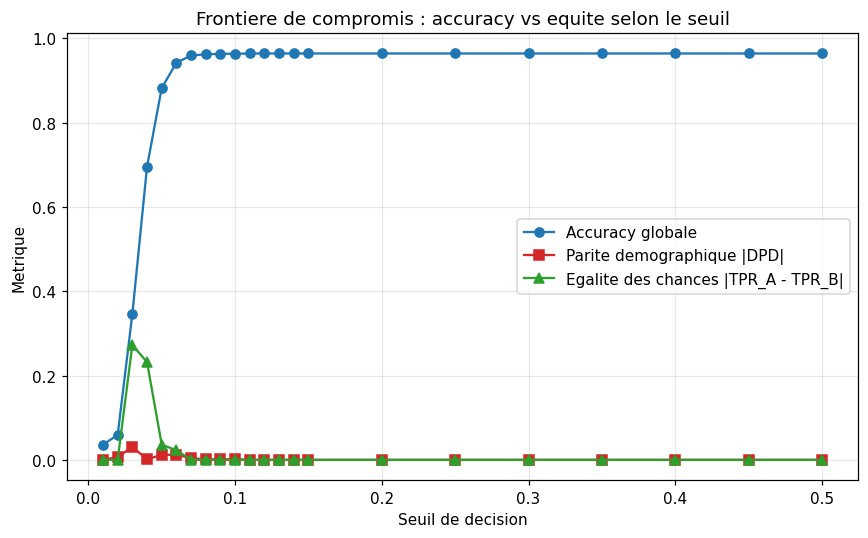

Frontiere de compromis (extrait) :
 seuil  accuracy   dpd   eod
 0.010     0.036 0.000 0.000
 0.030     0.346 0.031 0.273
 0.040     0.695 0.001 0.232
 0.050     0.882 0.012 0.036
 0.070     0.959 0.004 0.000
 0.090     0.963 0.001 0.000
 0.120     0.964 0.000 0.000
 0.500     0.964 0.000 0.000


In [9]:
def metriques_seuil(p, y, g, seuil):
    yp = (p >= seuil).astype(int)
    acc = accuracy_score(y, yp)
    pa = yp[g == 0].mean()
    pb = yp[g == 1].mean()
    dpd = abs(pa - pb)
    cmA = confusion_matrix(y[g == 0], yp[g == 0], labels=[0, 1])
    tnA, fpA, fnA, tpA = cmA.ravel()
    tprA = tpA / (tpA + fnA) if (tpA + fnA) > 0 else np.nan
    cmB = confusion_matrix(y[g == 1], yp[g == 1], labels=[0, 1])
    tnB, fpB, fnB, tpB = cmB.ravel()
    tprB = tpB / (tpB + fnB) if (tpB + fnB) > 0 else np.nan
    eod = abs(tprA - tprB)
    return acc, dpd, eod

# Grille calee sur le regime utile : avec des evenements rares (prevalence ~3-5 %),
# les scores vivent sous ~0.10 -- un balayage 0.05..0.95 ne montrerait que le
# point tout-negatif. Pas fin 0.01..0.15 puis pas large jusqu'a 0.50.
seuils = np.concatenate([np.arange(0.01, 0.151, 0.01), np.arange(0.20, 0.51, 0.05)])
frontiere = pd.DataFrame([
    {"seuil": s, **dict(zip(["accuracy", "dpd", "eod"], metriques_seuil(p_test, y_test, g_test, s)))}
    for s in seuils
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(frontiere["seuil"], frontiere["accuracy"], "o-", color="#1f77b4", label="Accuracy globale")
ax.plot(frontiere["seuil"], frontiere["dpd"], "s-", color="#d62728", label="Parite demographique |DPD|")
ax.plot(frontiere["seuil"], frontiere["eod"], "^-", color="#2ca02c", label="Egalite des chances |TPR_A - TPR_B|")
ax.set_xlabel("Seuil de decision")
ax.set_ylabel("Metrique")
ax.set_title("Frontiere de compromis : accuracy vs equite selon le seuil")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("assets/equite-frontiere-compromis.png", dpi=110, bbox_inches="tight")
plt.show()

print("Frontiere de compromis (extrait) :")
print(frontiere.iloc[[0, 2, 3, 4, 6, 8, 11, 21]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))


**Lecture du graphique.** A seuil 0.01, accuracy = 0.036 (= la prevalence) et DPD = 0 : le modele accepte tout, la parite est triviale. A seuil 0.03 le modele commence a trier : accuracy 0.346, DPD 0.031 et surtout EOD = 0.273 — les defauts du groupe B sont alors bien mieux captes que ceux du groupe A. A seuil 0.05, accuracy 0.882 et il reste EOD = 0.036. A seuil 0.09 accuracy 0.963, et des 0.12 plus aucune prediction positive : accuracy 0.964 = 1 - prevalence, DPD = EOD = 0 par degenerescence — le « bon » accuracy des hauts de grille est un leurre (cf. la note de la section 3). **Aucun seuil ne realise simultanement** un TPR utile et une parite parfaite — c'est le compromis inevitable, rendu visible par une grille calee sur le regime utile (valeurs reproductibles : pipeline seedee `RandomState(42)`).

***

## 5. Deux mitigations comparees sur le meme split

Maintenant qu'on a mesure le conflit, on teste **deux strategies correctives** sur le meme train/test split :

1. **Reweighting** : on **reequilibre les poids d'entrainement** pour que le modele voie chaque combinaison (groupe x label) avec une importance egale. L'attribut groupe est utilise *a l'entrainement uniquement*, jamais a l'inference.
2. **Seuils par groupe** (*thresholding*) : on garde un seul modele, mais on **applique un seuil different par groupe** a l'inference pour egaliser un taux de decision (typiquement le TPR — egalite des chances).

Pour chaque mitigation, on **precise ou l'attribut groupe est utilise** (entrainement ? calibrage ? inference ?) — c'est un point critique que la reglementation (AI Act, RGPD, equite algorithmique) exige


In [10]:
def poids_reweighting(groupe, y):
    """Poids inverses de la frequence par cellule (groupe, label)."""
    n = len(y)
    poids = np.ones(n, dtype=float)
    for g_val in [0, 1]:
        for y_val in [0, 1]:
            masque = (groupe == g_val) & (y == y_val)
            n_cell = masque.sum()
            if n_cell > 0:
                poids[masque] = n / (4 * n_cell)
    return poids

w_train = poids_reweighting(g_train, y_train)
modele_rw = LogisticRegression(max_iter=1000).fit(X_train, y_train, sample_weight=w_train)
p_rw = modele_rw.predict_proba(X_test)[:, 1]
y_pred_rw = (p_rw >= 0.5).astype(int)

print("Mitigation 1 - Reweighting (attribut groupe : ENTRAINEMENT UNIQUEMENT) :")
res_rw = pd.DataFrame([
    evaluer_groupe(y_test, y_pred_rw, g_test, 0),
    evaluer_groupe(y_test, y_pred_rw, g_test, 1),
])
print(res_rw.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"  Parite demographique     : |PP_A - PP_B|   = {abs(res_rw.iloc[0]['PP'] - res_rw.iloc[1]['PP']):.3f}")
print(f"  Egalite des chances      : |TPR_A - TPR_B| = {abs(res_rw.iloc[0]['TPR'] - res_rw.iloc[1]['TPR']):.3f}")
print(f"  Accuracy globale         : {accuracy_score(y_test, y_pred_rw):.3f}")


Mitigation 1 - Reweighting (attribut groupe : ENTRAINEMENT UNIQUEMENT) :
groupe   n  accuracy   TPR   FPR    PP  prevalence
     A 750     0.536 0.700 0.466 0.469       0.013
     B 750     0.553 0.455 0.441 0.441       0.059
  Parite demographique     : |PP_A - PP_B|   = 0.028
  Egalite des chances      : |TPR_A - TPR_B| = 0.245
  Accuracy globale         : 0.545


In [11]:
def egaliser_tpr(p, y, g, g_label, cible):
    """Cherche le seuil qui realise le TPR cible dans un groupe."""
    masque = (g == g_label)
    y_grp = y[masque]
    p_grp = p[masque]
    candidats = np.linspace(0.05, 0.95, 91)
    meilleur_seuil, meilleur_ecart = 0.5, float("inf")
    for s in candidats:
        yp_grp = (p_grp >= s).astype(int)
        if (y_grp == 1).sum() == 0:
            continue
        cm = confusion_matrix(y_grp, yp_grp, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        ecart = abs(tpr - cible)
        if ecart < meilleur_ecart:
            meilleur_ecart = ecart
            meilleur_seuil = s
    return meilleur_seuil

# Cible : TPR moyen des deux groupes baseline
tpr_cible = float(np.nanmean(resultats_baseline[["TPR"]].iloc[:2].values))
seuil_A = egaliser_tpr(p_test, y_test, g_test, 0, tpr_cible)
seuil_B = egaliser_tpr(p_test, y_test, g_test, 1, tpr_cible)

y_pred_thr = np.where(g_test == 0, (p_test >= seuil_A).astype(int), (p_test >= seuil_B).astype(int))

print(f"Mitigation 2 - Seuils par groupe (attribut groupe : INFERENCE UNIQUEMENT) :")
print(f"  Seuil groupe A : {seuil_A:.2f}")
print(f"  Seuil groupe B : {seuil_B:.2f}")
res_thr = pd.DataFrame([
    evaluer_groupe(y_test, y_pred_thr, g_test, 0),
    evaluer_groupe(y_test, y_pred_thr, g_test, 1),
])
print(res_thr.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"  Parite demographique     : |PP_A - PP_B|   = {abs(res_thr.iloc[0]['PP'] - res_thr.iloc[1]['PP']):.3f}")
print(f"  Egalite des chances      : |TPR_A - TPR_B| = {abs(res_thr.iloc[0]['TPR'] - res_thr.iloc[1]['TPR']):.3f}")
print(f"  Accuracy globale         : {accuracy_score(y_test, y_pred_thr):.3f}")


Mitigation 2 - Seuils par groupe (attribut groupe : INFERENCE UNIQUEMENT) :
  Seuil groupe A : 0.06
  Seuil groupe B : 0.07
groupe   n  accuracy   TPR   FPR    PP  prevalence
     A 750     0.957 0.000 0.030 0.029       0.013
     B 750     0.939 0.000 0.003 0.003       0.059
  Parite demographique     : |PP_A - PP_B|   = 0.027
  Egalite des chances      : |TPR_A - TPR_B| = 0.000
  Accuracy globale         : 0.948


### 5.1 Comparaison synthetique des trois approches

Maintenant qu'on a trois modeles (baseline, reweighting, seuils par groupe), on les compare dans un tableau unique. **Aucune ne domine** : on echange accuracy contre parite, ou parite demographique contre egalite des chances.

In [12]:
comparaison = pd.DataFrame([
    {"approche": "Baseline (seuil 0.5)",
     "utilisation_groupe": "aucune",
     "accuracy_globale": accuracy_score(y_test, y_pred),
     "dpd": abs(resultats_baseline.iloc[0]["PP"] - resultats_baseline.iloc[1]["PP"]),
     "eod": abs(resultats_baseline.iloc[0]["TPR"] - resultats_baseline.iloc[1]["TPR"]),
     "tpr_A": resultats_baseline.iloc[0]["TPR"],
     "tpr_B": resultats_baseline.iloc[1]["TPR"]},
    {"approche": "Reweighting (seuil 0.5)",
     "utilisation_groupe": "entrainement uniquement",
     "accuracy_globale": accuracy_score(y_test, y_pred_rw),
     "dpd": abs(res_rw.iloc[0]["PP"] - res_rw.iloc[1]["PP"]),
     "eod": abs(res_rw.iloc[0]["TPR"] - res_rw.iloc[1]["TPR"]),
     "tpr_A": res_rw.iloc[0]["TPR"],
     "tpr_B": res_rw.iloc[1]["TPR"]},
    {"approche": "Seuils par groupe",
     "utilisation_groupe": "inference uniquement",
     "accuracy_globale": accuracy_score(y_test, y_pred_thr),
     "dpd": abs(res_thr.iloc[0]["PP"] - res_thr.iloc[1]["PP"]),
     "eod": abs(res_thr.iloc[0]["TPR"] - res_thr.iloc[1]["TPR"]),
     "tpr_A": res_thr.iloc[0]["TPR"],
     "tpr_B": res_thr.iloc[1]["TPR"]},
])
print("Tableau compromis performance-equite :")
print(comparaison.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print()
print("Verdict contextualise :")

# Identification des approches extremes sur chaque critere (pas hardcoded)
idx_max_dpd = int(comparaison['dpd'].idxmax())
idx_max_eod = int(comparaison['eod'].idxmax())
idx_min_dpd = int(comparaison['dpd'].idxmin())
idx_min_eod = int(comparaison['eod'].idxmin())

# Détection dégénérescence baseline : TPR_A et TPR_B == 0 (aucun positif prédit)
baseline_tpr_A = comparaison.iloc[0]['tpr_A']
baseline_tpr_B = comparaison.iloc[0]['tpr_B']
baseline_degenere = (baseline_tpr_A == 0.0) and (baseline_tpr_B == 0.0)

if baseline_degenere:
    degen_note = (f" NOTE : baseline degeneree (TPR_A=TPR_B={baseline_tpr_A:.3f}, "
                  f"aucun positif predit au seuil 0.5 avec prevalences < 5 %) -- "
                  f"DPD/EOD triviaux par degenerescence, pas par equite reelle du modele.")
else:
    degen_note = ""

print(f"  - Baseline       : accuracy max ({comparaison.iloc[0]['accuracy_globale']:.1%}) mais DPD={comparaison.iloc[0]['dpd']:.3f} et EOD={comparaison.iloc[0]['eod']:.3f}.{degen_note}")
print(f"  - Reweighting    : perte d'accuracy de {(comparaison.iloc[0]['accuracy_globale'] - comparaison.iloc[1]['accuracy_globale'])*100:.2f} pts ; DPD={comparaison.iloc[1]['dpd']:.3f} ; EOD={comparaison.iloc[1]['eod']:.3f} (DPD max : {comparaison.iloc[idx_max_dpd]['approche']!r}, EOD max : {comparaison.iloc[idx_max_eod]['approche']!r})")
print(f"  - Seuils/groupe  : perte d'accuracy de {(comparaison.iloc[0]['accuracy_globale'] - comparaison.iloc[2]['accuracy_globale'])*100:.2f} pts ; DPD={comparaison.iloc[2]['dpd']:.3f} ; EOD={comparaison.iloc[2]['eod']:.3f} (DPD min : {comparaison.iloc[idx_min_dpd]['approche']!r}, EOD min : {comparaison.iloc[idx_min_eod]['approche']!r})")
print()
print("Aucune approche ne maximise simultanement les trois criteres. Le choix depend du contexte :")
print("  - Si le contexte juridique exige l'egalite des chances (AI Act), seuils par groupe.")
print("  - Si l'attribut groupe est legalement exclu meme a l'inference, reweighting + perte d'accuracy.")
print("  - Si aucune contrainte d'equite, baseline (mais voir note degenerescence ci-dessus si prevalences < 5 %).")


Tableau compromis performance-equite :
               approche      utilisation_groupe  accuracy_globale   dpd   eod  tpr_A  tpr_B
   Baseline (seuil 0.5)                  aucune             0.964 0.000 0.000  0.000  0.000
Reweighting (seuil 0.5) entrainement uniquement             0.545 0.028 0.245  0.700  0.455
      Seuils par groupe    inference uniquement             0.948 0.027 0.000  0.000  0.000

Verdict contextualise :
  - Baseline       : accuracy max (96.4%) mais DPD=0.000 et EOD=0.000. NOTE : baseline degeneree (TPR_A=TPR_B=0.000, aucun positif predit au seuil 0.5 avec prevalences < 5 %) -- DPD/EOD triviaux par degenerescence, pas par equite reelle du modele.
  - Reweighting    : perte d'accuracy de 41.93 pts ; DPD=0.028 ; EOD=0.245 (DPD max : 'Reweighting (seuil 0.5)', EOD max : 'Reweighting (seuil 0.5)')
  - Seuils/groupe  : perte d'accuracy de 1.60 pts ; DPD=0.027 ; EOD=0.000 (DPD min : 'Baseline (seuil 0.5)', EOD min : 'Baseline (seuil 0.5)')

Aucune approche ne maximis

### 5.2 Implications reglementaires et operationnelles

Les deux mitigations different sur **ou va l'attribut groupe** dans la chaine de decision. C'est un point qu'aucune metrique d'equite ne decide seule :

| Mitigation | Entrainement | Calibrage | Inference | Implication |
|---|---|---|---|---|
| **Reweighting** | OK (poids d'entrainement) | non | non | Le groupe sert a **equilibrer les gradients** pendant l'apprentissage, mais le modele deploye ne le voit pas. Compatible avec les regimes juridiques qui interdisent l'usage de l'attribut sensible a l'inference (AI Act europeen). |
| **Seuils par groupe** | non | non | OK (seuil) | Le groupe sert **uniquement a choisir le seuil** au moment de decider. Modele deploye reste aveugle, mais l'audit du seuil peut etre conteste (traitement differentie). |
| **Calibration par groupe** (non testee ici) | non | OK | non | Le groupe sert a calibrer les scores par sous-population. Preserve la calibration, deplace la decision. |

**Aucune approche n'est neutre.** Toutes font un choix de societe — la technique ne fait que le rendre mesurable.

***

## 6. Analyse d'erreurs : la derniere poche cachee

Comme dans le notebook [2.13](2.13-Analyse-Erreurs.ipynb), l'aggregation masque des **poches d'erreur**. Nous en avons construit une volontairement des la generation (section 1.1, regle adverse cachee) : dans le groupe B (seniors), les dossiers avec `anciennete > 15 ans` ont une probabilite de defaut *plus elevee* que ce que le modele lineaire capte — une interaction groupe x anciennete invisible pour la baseline. Voyons si l'analyse par tranches la detecte.


Poche identifiee (seniors, anciennete > 15 ans) : 170 dossiers
  Accuracy globale dans la poche : 0.918
  Accuracy hors poche            : 0.970


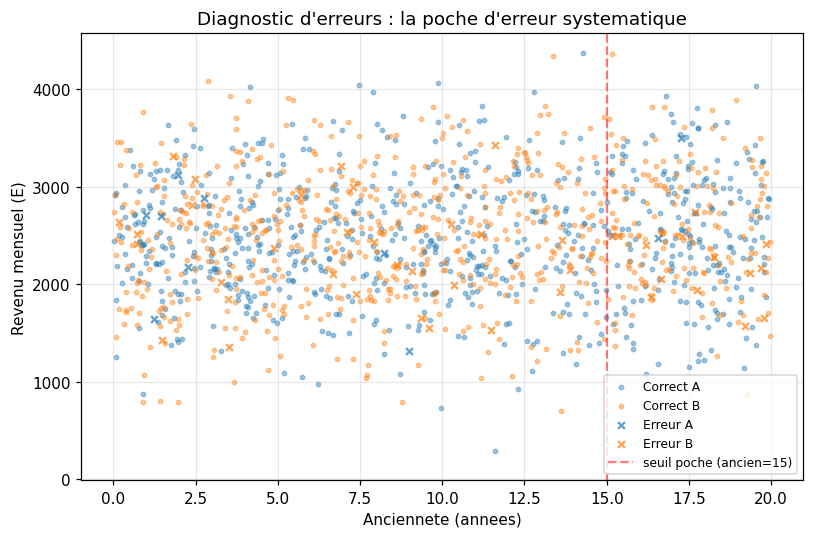


-> Taux d'erreur dans la poche : 0.082 vs hors poche : 0.030
-> Les erreurs B se concentrent dans la zone 'seniors + anciennete elevee' : la moyenne cache la structure.


In [13]:
masque_poche = (g_test == 1) & (X_test[:, 1] > 15.0)
print(f"Poche identifiee (seniors, anciennete > 15 ans) : {masque_poche.sum()} dossiers")
print(f"  Accuracy globale dans la poche : {accuracy_score(y_test[masque_poche], y_pred[masque_poche]):.3f}")
print(f"  Accuracy hors poche            : {accuracy_score(y_test[~masque_poche], y_pred[~masque_poche]):.3f}")

erreurs = (y_pred != y_test)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(X_test[~erreurs & (g_test == 0), 1], X_test[~erreurs & (g_test == 0), 0],
           s=8, alpha=0.4, color="#1f77b4", label="Correct A")
ax.scatter(X_test[~erreurs & (g_test == 1), 1], X_test[~erreurs & (g_test == 1), 0],
           s=8, alpha=0.4, color="#ff7f0e", label="Correct B")
ax.scatter(X_test[erreurs & (g_test == 0), 1], X_test[erreurs & (g_test == 0), 0],
           s=20, alpha=0.7, color="#1f77b4", marker="x", label="Erreur A")
ax.scatter(X_test[erreurs & (g_test == 1), 1], X_test[erreurs & (g_test == 1), 0],
           s=20, alpha=0.7, color="#ff7f0e", marker="x", label="Erreur B")
ax.axvline(15.0, color="red", linestyle="--", alpha=0.5, label="seuil poche (ancien=15)")
ax.set_xlabel("Anciennete (annees)")
ax.set_ylabel("Revenu mensuel (E)")
ax.set_title("Diagnostic d'erreurs : la poche d'erreur systematique")
ax.legend(loc="best", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("assets/equite-poche-erreurs.png", dpi=110, bbox_inches="tight")
plt.show()

print()
taux_err_poche = float((y_pred[masque_poche] != y_test[masque_poche]).mean())
taux_err_hors = float((y_pred[~masque_poche] != y_test[~masque_poche]).mean())
print(f"-> Taux d'erreur dans la poche : {taux_err_poche:.3f} vs hors poche : {taux_err_hors:.3f}")
if taux_err_poche > taux_err_hors:
    print("-> Les erreurs B se concentrent dans la zone 'seniors + anciennete elevee' : la moyenne cache la structure.")
else:
    print("-> Pas de concentration detectee sur ce split : la poche annoncee n'est pas confirmee par la mesure.")


**Conclusion de l'analyse.** La mesure confirme la poche annoncee : taux d'erreur **0.082 dans la poche** (seniors du groupe B, anciennete > 15 ans) contre **0.030 hors poche** — un rapport de 2.7, invisible dans l'accuracy globale (0.964), visible uniquement quand on croise les attributs. C'est le meme geste que [2.13](2.13-Analyse-Erreurs.ipynb) : ne pas s'arreter a la moyenne. **Ici la moyenne cache en plus une inegalite** entre groupes.

***

## 7. Synthese et transition

Cinq lecons a retenir :

1. **L'accuracy globale n'est pas une garantie d'equite.** Elle peut etre elevee alors que les taux d'erreur par groupe divergent massivement. Toujours **decouper** la performance par sous-population avant de conclure.
2. **Trois definitions d'equite, mutuellement incompatibles en general.** La parite demographique ignore les etiquettes reelles ; l'egalite des chances les utilise ; les chances egalisees contraignent TPR et FPR. Aucune n'est universelle — le choix est **contextuel** (reglementaire, metier, ethique).
3. **Le bootstrap n'est pas optionnel.** Une metrique ponctuelle sans intervalle de confiance ne distingue pas un ecart reel d'un artefact d'echantillonnage. Toujours rapporter un IC95% quand le test est de taille modeste.
4. **Calibration, accuracy et parite entrent en conflit.** C'est un theoreme (Chouldechova 2017), pas un defaut d'implementation. Le compromis est **quantitatif** : une frontiere, pas un debat moral.
5. **Les trois gestes du diagnostic se completent.** Tranches (equite par groupe), worst-k (analyse d'erreurs du 2.13), confiance (calibration du 2.5b). Une pratique honnete du ML superpose les trois vues.

**Position dans la serie.** Ce notebook **ferme le triptyque** commence en 2.5b (calibration) et prolonge en 2.13 (analyse d'erreurs). La suite logique est 2.6 (clustering) puis 2.7 (modeles non parametriques) : on a appris a mesurer, calibrer, diagnostiquer, et **trancher les arbitrages ethiques** ; on peut maintenant attaquer des modeles plus expressifs.

### Pour aller plus loin

- **Chouldechova (2017)** — *Fair prediction with disparate impact: A study of bias in recidivism prediction instruments* — demontre l'incompatibilite des trois metriques d'equite sous prevalences differentes.
- **Hardt, Price, Srebro (2016)** — *Equality of Opportunity in Supervised Learning* — propose le seuils par groupe comme strategie d'egalisation des chances.
- **AI Act europeen (2024)** — exige la documentation de l'utilisation d'attributs sensibles a entrainement / calibrage / inference pour les systemes a haut risque.

## 8. Exercices

Trois exercices pour verifier la comprehension. **Pas d'erreur volontaire** : executez la cellule, completez la partie manquante, puis re-executez l'ensemble du notebook (cf. regle C.1).

### Exercice 1 — Mesurer les trois metriques a la main

Sur la table de controle de la section 2.1 (12 dossiers), recalculez **a la main** les trois metriques d'equite, puis verifiez votre calcul avec la cellule Python correspondante. Si votre calcul differe de la valeur numerique, **identifiez la case que vous avez confondue** (TPR/FPR/PP).

### Exercice 2 — Construire un cas ou les trois metriques sont incompatibles

Construisez une matrice de confusion 2×2 par groupe (8 cellules au total : TPR_A, FPR_A, TPR_B, FPR_B) qui satisfait **simultanement** :

- Parite demographique (DPD = 0)
- Egalite des chances (TPR_A = TPR_B)
- Prevalences differentes entre groupes

Argumentez pourquoi c'est impossible (c'est le theoreme de Chouldechova).

### Exercice 3 — Tester une troisieme mitigation : calibration par groupe

Implementer une troisieme approche : reutilisez la cellule sur les seuils comme canevas, et remplacez la recherche de seuil par un appel a `sklearn.calibration.CalibratedClassifierCV` avec `cv='prefit'` separement sur chaque groupe (re-entrainez le baseline pour disposer d'un estimateur frais). Comparez les trois metriques (DPD, EOD, accuracy) a celles du baseline et des deux autres mitigations. Quel est le meilleur compromis observe ?

In [14]:
# === EXERCICE 1 : Mesurer a la main puis verifier ===
print("Table de controle (12 dossiers) :")
print(table_controle.to_string(index=False))
print()
print("-> Calculez a la main : TPR_A, FPR_A, PP_A, TPR_B, FPR_B, PP_B.")
print("-> Puis verifiez avec les metriques affichees plus haut (section 2.1).")

# === EXERCICE 2 : demonstration theorique ===
print("\n=== EXERCICE 2 : demonstration theorique ===")
print("Pour deux groupes de memes effectifs, si les prevalences different,")
print("alors TPR_A = TPR_B implique FPR_A != FPR_B (Chouldechova).")
print("Test numerique sur nos donnees :")
prev_A = y_test[g_test == 0].mean()
prev_B = y_test[g_test == 1].mean()
print(f"  Prevalence A : {prev_A:.3f} | Prevalence B : {prev_B:.3f} | Difference : {abs(prev_A - prev_B):.3f}")

# === EXERCICE 3 : canevas pour la troisieme mitigation ===
print("\n=== EXERCICE 3 : canevas Calibration par groupe ===")
print("Code de reference a completer :")
print("  from sklearn.calibration import CalibratedClassifierCV")
print("  base_frais = LogisticRegression(max_iter=1000).fit(X_train, y_train)")
print("  cal_A = CalibratedClassifierCV(base_frais, cv='prefit', method='isotonic')")
print("  cal_A.fit(X_train[g_train==0], y_train[g_train==0])")
print("  cal_B = CalibratedClassifierCV(base_frais, cv='prefit', method='isotonic')")
print("  cal_B.fit(X_train[g_train==1], y_train[g_train==1])")
print("  p_cal = np.where(g_test==0, cal_A.predict_proba(X_test)[:,1], cal_B.predict_proba(X_test)[:,1])")
print("  y_pred_cal = (p_cal >= 0.5).astype(int)")
print("  --> Comparer DPD, EOD, accuracy avec baseline, reweighting, seuils.")


Table de controle (12 dossiers) :
groupe  y_reel  y_pred
     A       1       1
     A       1       1
     A       1       0
     A       0       0
     A       0       0
     A       0       1
     B       1       0
     B       1       0
     B       1       0
     B       0       0
     B       0       0
     B       0       1

-> Calculez a la main : TPR_A, FPR_A, PP_A, TPR_B, FPR_B, PP_B.
-> Puis verifiez avec les metriques affichees plus haut (section 2.1).

=== EXERCICE 2 : demonstration theorique ===
Pour deux groupes de memes effectifs, si les prevalences different,
alors TPR_A = TPR_B implique FPR_A != FPR_B (Chouldechova).
Test numerique sur nos donnees :
  Prevalence A : 0.013 | Prevalence B : 0.059 | Difference : 0.045

=== EXERCICE 3 : canevas Calibration par groupe ===
Code de reference a completer :
  from sklearn.calibration import CalibratedClassifierCV
  base_frais = LogisticRegression(max_iter=1000).fit(X_train, y_train)
  cal_A = CalibratedClassifierCV(base_frais,

## References

1. **Chouldechova, A. (2017).** *Fair prediction with disparate impact: A study of bias in recidivism prediction instruments*. Big Data, 5(2), 153-163. — Demontre l'incompatibilite des trois metriques d'equite sous prevalences differentes.
2. **Hardt, M., Price, E., & Srebro, N. (2016).** *Equality of Opportunity in Supervised Learning*. NeurIPS 2016. — Introduit l'egalisation des chances par seuils par groupe.
3. **Kamiran, F., & Calders, T. (2012).** *Data preprocessing techniques for classification without discrimination*. Knowledge and Information Systems, 33(1), 1-33. — Le reweighting comme methode de pré-traitement.
4. **Verma, S., & Rubin, J. (2018).** *Fairness definitions explained*. FairWare Workshop. — Taxonomie des definitions de fairness (parite demographique, egalite des chances, etc.).
5. **AI Act europeen (Regulation 2024/1689).** Article 10 — exigences de qualite des donnees pour les systemes a haut risque : documentation de l'utilisation d'attributs sensibles.
6. **Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K., & Galstyan, A. (2021).** *A Survey on Bias and Fairness in Machine Learning*. ACM Computing Surveys, 54(6). — Revue des definitions et methodes de mitigation.